In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, levene, mannwhitneyu, normaltest, kruskal, shapiro, probplot
from itertools import combinations
from IPython.display import Image, display

Датасет содержит реальную информацию о заказах, оформленных в бразильском интернет-магазине Olist Store с 2016 по 2018 г.  
В данном исследовании проводится анализ структуры и динамики заказов, включая характеристики покупателей, продуктов, выручки и отзывов на заказы  
Data source: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

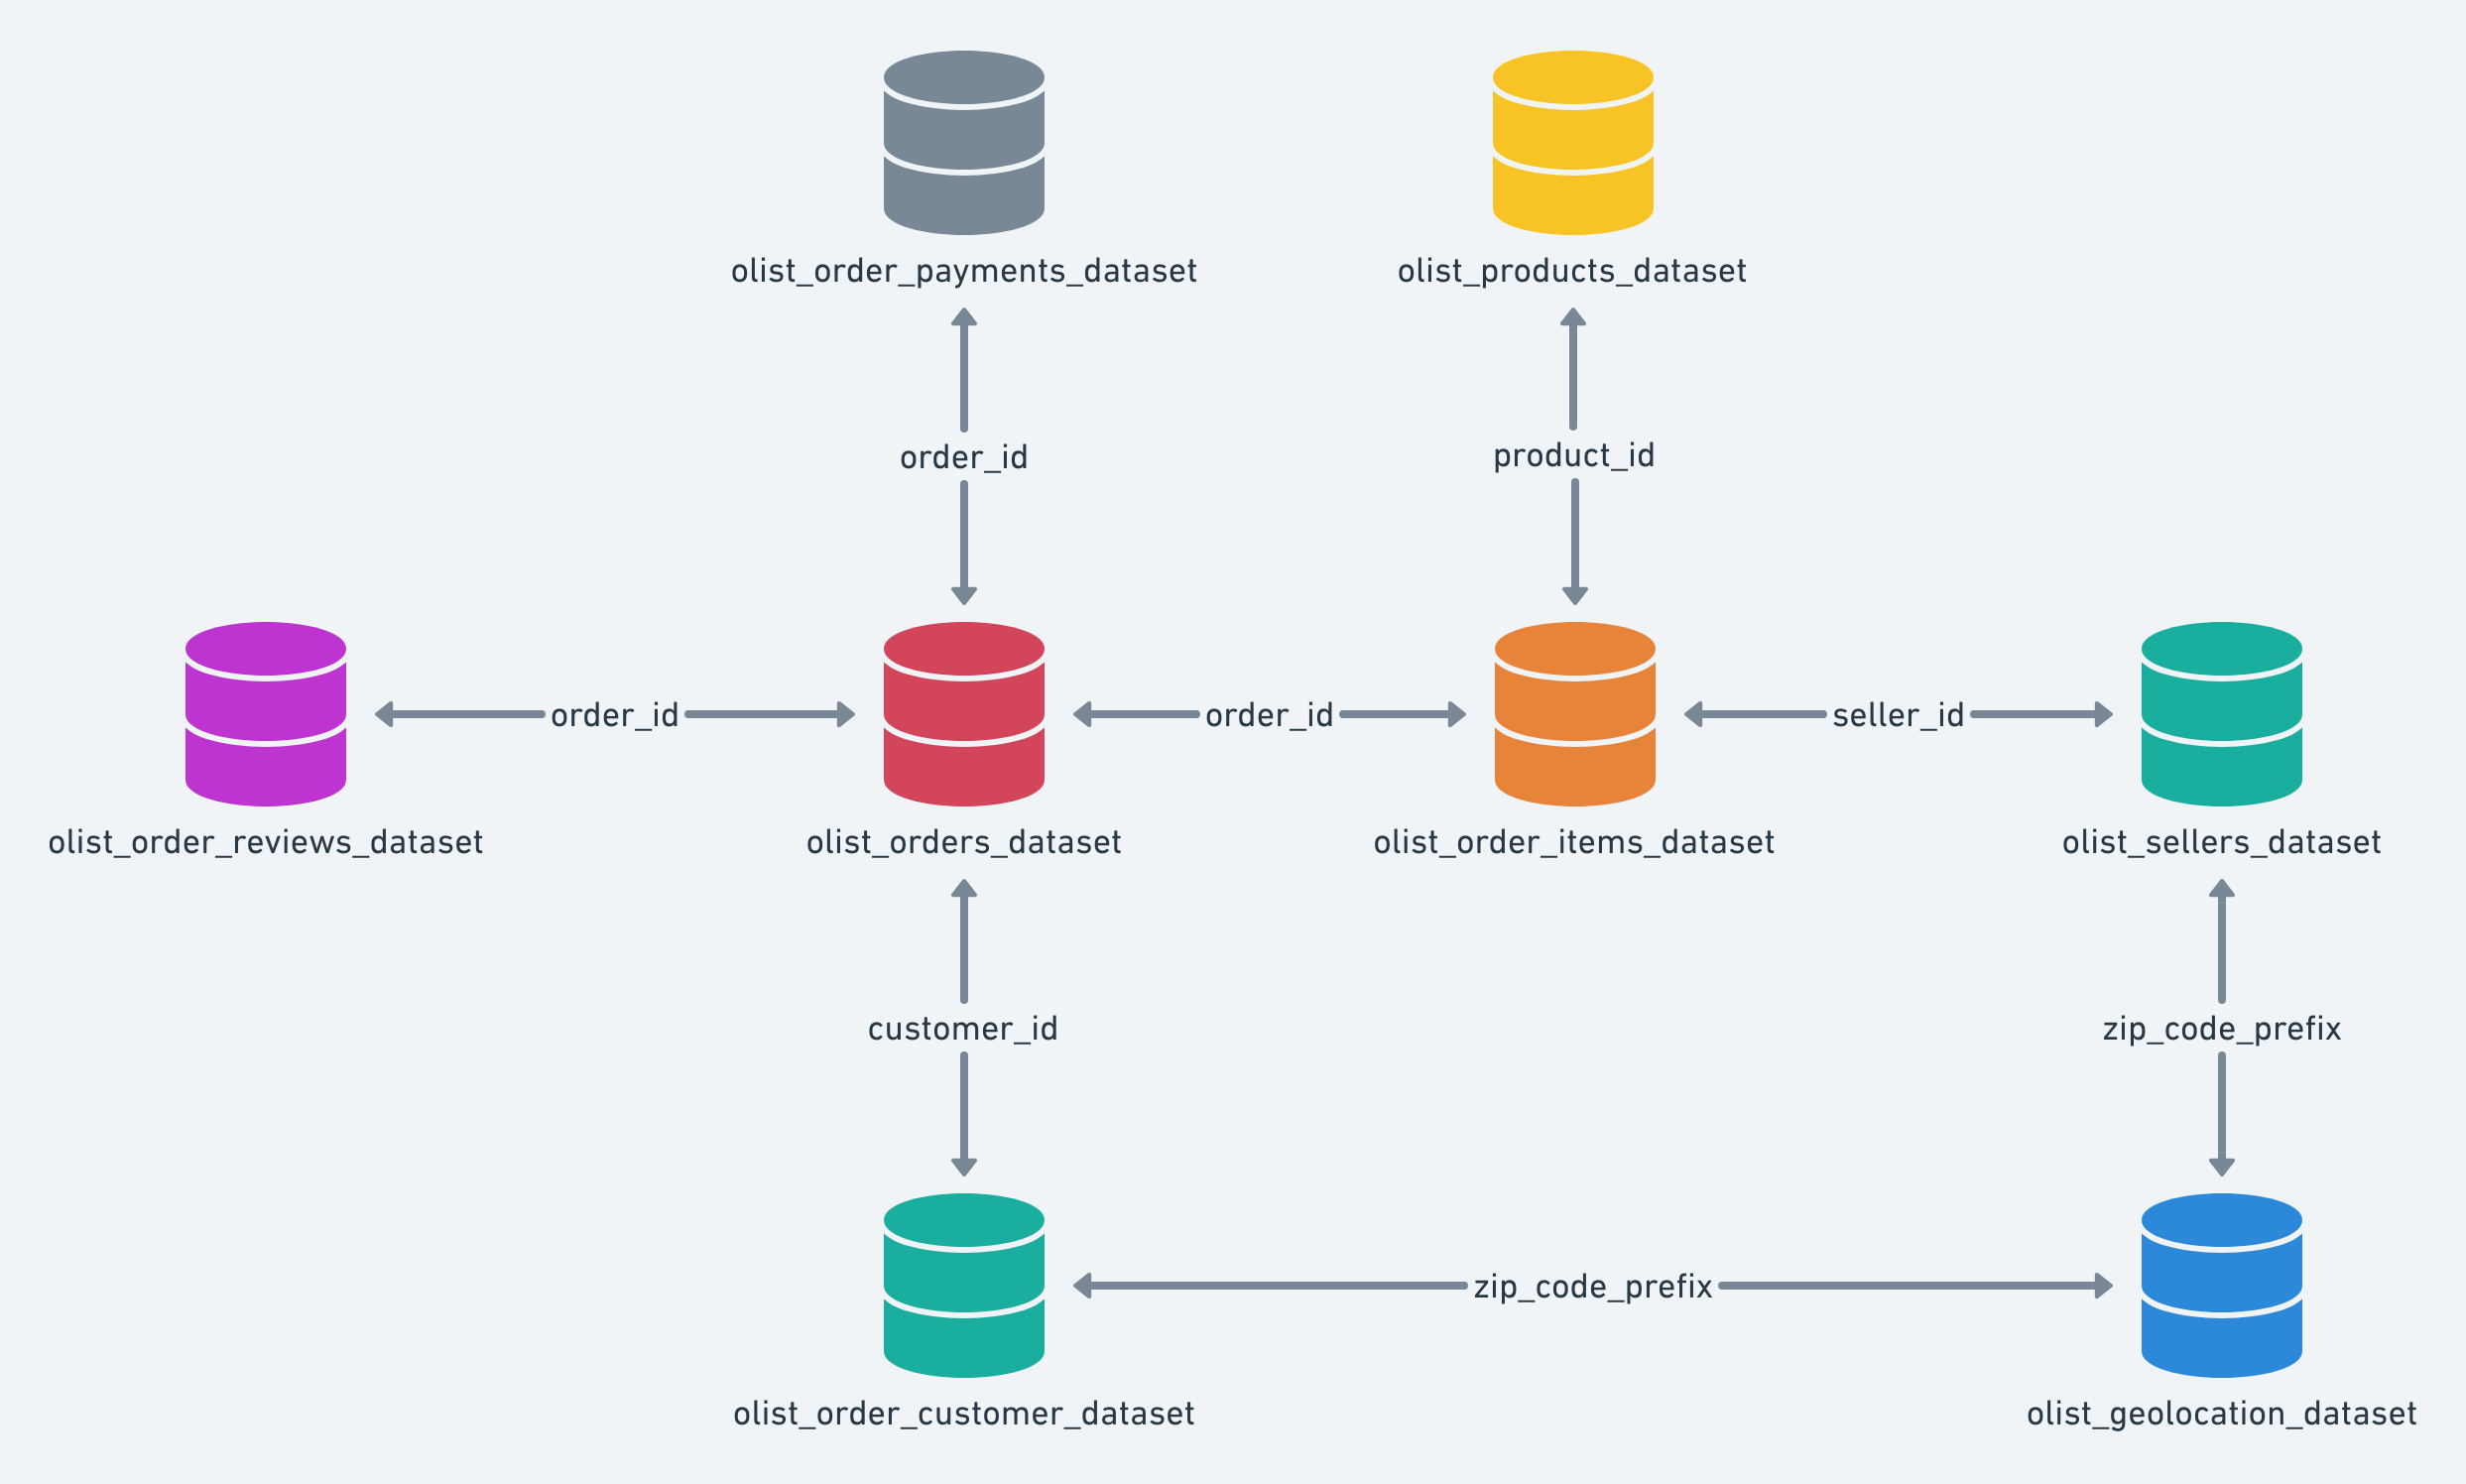

In [3]:
display(Image(filename='data schema.png', width=600))

# Data Loading

In [5]:
orders = pd.read_csv('olist_orders_dataset.csv', delimiter=',')
order_payments = pd.read_csv('olist_order_payments_dataset.csv', delimiter=',')
order_items = pd.read_csv('olist_order_items_dataset.csv', delimiter=',')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv', delimiter=',')
customers = pd.read_csv('olist_customers_dataset.csv', delimiter=',')
products = pd.read_csv('olist_products_dataset.csv', delimiter=',')
sellers = pd.read_csv('olist_sellers_dataset.csv', delimiter=',')
geolocation = pd.read_csv('olist_geolocation_dataset.csv', delimiter=',')
product_category_name = pd.read_csv('product_category_name_translation.csv', delimiter=',')

# Data Overview

## Orders

In [8]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [9]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


Всего имеется 99441 запись о заказах, включая уникальные идентификаторы заказов и покупателей, статусы заказов, а также даты и время оформления и подтверждения, передачи в доставку перевозчику, фактической и ожидаемой доставки заказа покупателю

## Payments

In [12]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [13]:
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


В данной таблице содержатся сведения о платежах, включая номер заказа, тип оплаты, а также информацию о разделении платежей на части и сумме оплаты

## Items

In [16]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [17]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


В таблице order_items перечислены id позиций, входящих в заказы, id продавцов этих товаров, крайние даты доставки, а также цены товаров и стоимости их перевозки

## Reviews

In [20]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [21]:
order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


Таблица хранит данные об отзывах на заказы: оценка заказа, заголовок и комментарий к отзыву, дата и время создания отзыва, а также дата и время ответа на отзыв

## Customers

In [24]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [25]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


Первичный ключ данной таблицы, связывающий ее с таблицей orders - поле customer_id, уникальное значение каждой пары заказ-покупатель  
Уникальный идентификатор каждого клиента - поле customer_unique_id  
Для каждого заказа (пары заказ-покупатель) указаны префикс почтового индекса покупателя, а также город и штат доставки

## Products

In [28]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [29]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


Таблица products содержит данные о категории каждого товара, длинах его названия и описания, количестве фотографий товара, его массе и измерениях

## Sellers

In [32]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [33]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


Для каждого продавца в таблице указан префикс его почтового индекса, а также город и штат

## Geolocation

In [36]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [37]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


Каждый префикс почтового индекса содержит информацию о штате и городе и характеризуется координатами расположения (широтой и долготой)

## Product categories

In [40]:
product_category_name.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [41]:
product_category_name.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


Данная таблица содержит переводы наименований категорий товаров из таблицы product с португальского на английский

# Data Cleaning

In [44]:
orders_nan = pd.DataFrame({
    'NaN_count': orders.isna().sum(),
    'NaN_percent': round(orders.isna().mean() * 100, 2)
})

orders_nan.index.name = 'orders'
orders_nan

,NaN_count,NaN_percent
orders,,
order_id,0,0.00
customer_id,0,0.00
order_status,0,0.00
order_purchase_timestamp,0,0.00
order_approved_at,160,0.16
order_delivered_carrier_date,1783,1.79
order_delivered_customer_date,2965,2.98
order_estimated_delivery_date,0,0.00


В таблице заказов пропуски в столбцах даты и времени подтверждения заказа, передачи его в доставку и фактической доставки чаще всего обусловлены тем, что заказ на время среза данных находился в более раннем статусе, поэтому нет необходимости удалять строки с этими пропусками или их обрабатывать

In [46]:
order_reviews_nan = pd.DataFrame({
    'NaN_count': order_reviews.isna().sum(),
    'NaN_percent': round(order_reviews.isna().mean() * 100, 2)
})

order_reviews_nan.index.name = 'order_reviews'
order_reviews_nan

,NaN_count,NaN_percent
order_reviews,,
review_id,0,0.00
order_id,0,0.00
review_score,0,0.00
review_comment_title,87656,88.34
review_comment_message,58247,58.70
review_creation_date,0,0.00
review_answer_timestamp,0,0.00


Пропущенные значения в таблице отзывов на заказы содержатся в столбцах заголовка и текста комментария к заказу, занимают большую долю таблицы и будут полезны для анализа поведения покупателей, поэтому в их обработке также нет необходимости

In [48]:
products_nan = pd.DataFrame({
    'NaN_count': products.isna().sum(),
    'NaN_percent': round(products.isna().mean() * 100, 2)
})

products_nan.index.name = 'products'
products_nan

,NaN_count,NaN_percent
products,,
product_id,0,0.00
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


Для 1.85% товаров не указана категория, количество фотографий, а также длины названия и описания товара  
Для еще двух товаров не указаны масса и размеры

В остальных таблицах пропущенных значений нет

# Data Joining

Поскольку некоторые заказы оплачиваются несколькими разными способами (несколько payment_sequential), в заказе может быть несколько позиций и на некоторые заказы оставлено более 1 отзыва, полезно иметь соответствующие сгруппированные по order_id таблицы с агрегированными величинами:

In [53]:
items_per_order = order_items.groupby('order_id').agg(
    items_count=('order_item_id', 'count'),
    unique_products_count=('product_id', 'nunique'),
    price_sum=('price', 'sum'),
    freight_value_sum=('freight_value', 'sum')).reset_index()
items_per_order.head()

,order_id,items_count,unique_products_count,price_sum,freight_value_sum
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,199.90,18.14


In [54]:
payments_per_order = order_payments.groupby('order_id').agg(
    revenue=('payment_value','sum'),
    payment_types_count=('payment_type','nunique'),
    payment_installments_count=('payment_installments', 'sum'),
    payment_sequential_count=('payment_sequential', 'nunique')).reset_index()
payments_per_order.head()

,order_id,revenue,payment_types_count,payment_installments_count,payment_sequential_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,1,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,3,1


In [55]:
reviews_per_order = order_reviews.groupby('order_id').agg(avg_review_score=('review_score','mean')).reset_index()
reviews_per_order.head()

,order_id,avg_review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


Соединив данные таблицы с остальными таблицами, в которых order_id уникальны, получим основную таблицу для анализа:

In [57]:
df = orders.merge(customers, on='customer_id', how='left') \
    .merge(items_per_order, on='order_id', how='left') \
    .merge(payments_per_order, on='order_id', how='left') \
    .merge(reviews_per_order, on='order_id', how='left')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,customer_state,items_count,unique_products_count,price_sum,freight_value_sum,revenue,payment_types_count,payment_installments_count,payment_sequential_count,avg_review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,SP,1.0,1.0,29.99,8.72,38.71,2.0,3.0,3.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,BA,1.0,1.0,118.70,22.76,141.46,1.0,1.0,1.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,GO,1.0,1.0,159.90,19.22,179.12,1.0,3.0,1.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,RN,1.0,1.0,45.00,27.20,72.20,1.0,1.0,1.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,SP,1.0,1.0,19.90,8.72,28.62,1.0,1.0,1.0,5.0


# Feature engineering

In [59]:
df.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
items_count                      float64
unique_products_count            float64
price_sum                        float64
freight_value_sum                float64
revenue                          float64
payment_types_count              float64
payment_installments_count       float64
payment_sequential_count         float64
avg_review_score                 float64
dtype: object

Преобразуем поля с датой и временем к типу данных pd.datetime, а также для удобства и экономии памяти преобразуем поле order_status к категориальному типу данных:

In [61]:
timestamp_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
                     'order_delivered_customer_date', 'order_estimated_delivery_date']

df[timestamp_columns] = df[timestamp_columns].apply(pd.to_datetime)

In [62]:
df['order_status'] = pd.Categorical(df['order_status'])

Для дальнейшего анализа удобно добавить в таблицу следующие поля:
- delivery_time - время, прошедшее со времени оформления заказа до его доставки покупателю
- delivery_delay - время опоздания доставки (NaT для заказов, пришедших вовремя)

In [64]:
df['delivery_time'] = df['order_delivered_customer_date'].sub(df['order_purchase_timestamp'])

df['delivery_delay'] = df['order_delivered_customer_date'].sub(df['order_estimated_delivery_date'])
df['delivery_delay'] = df['delivery_delay'].where(df['delivery_delay'] >= pd.Timedelta(0))

# Analysis

## Order analysis

In [67]:
df_count = df['order_id'].nunique()
print(f'Всего заказов: {df_count}')

Всего заказов: 99441


### Distribution of orders statuses

In [69]:
print(f'Возможные статусы заказов: {", ".join(df['order_status'].unique())}')
status_counts = df['order_status'].value_counts()
status_counts.index.name = None
status_counts.name = 'Число заказов в определенном статусе'
status_counts

Возможные статусы заказов: delivered, invoiced, shipped, processing, unavailable, canceled, created, approved


delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: Число заказов в определенном статусе, dtype: int64

In [70]:
print(f'{round((status_counts['delivered'] + status_counts['shipped']) /
                status_counts.sum() * 100, 2)}% заказов доставлены или находятся в процессе доставки')

print(f'{round((status_counts['invoiced'] + status_counts['processing'] +
                status_counts['created'] + status_counts['approved']) /
               status_counts.sum() * 100, 2)}% заказов еще не переданы в доставку')

print(f'{round((status_counts['canceled'] + status_counts['unavailable']) /
               status_counts.sum() * 100, 2)}% заказов отменены или их статус недоступен')

98.13% заказов доставлены или находятся в процессе доставки
0.63% заказов еще не переданы в доставку
1.24% заказов отменены или их статус недоступен


## Customer analysis

In [72]:
customers_count = df['customer_unique_id'].nunique()
print(f'Число уникальных покупателей: {customers_count}')

Число уникальных покупателей: 96096


### Number of customer orders

In [74]:
customer_df_count = df.groupby('customer_unique_id')['order_id'].nunique().sort_values(ascending=False)
customer_df_count.index.name = 'id покупателя'
customer_df_count.name = 'Количество заказов пользователей'
customer_df_count

id покупателя
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
                                    ..
5657dfebff5868c4dc7e8355fea865c4     1
5657596addb4d7b07b32cd330614bdf8     1
5656eb169546146caeab56c3ffc3d268     1
5656a8fabc8629ff96b2bc14f8c09a27     1
ffffd2657e2aad2907e67c3e9daecbeb     1
Name: Количество заказов пользователей, Length: 96096, dtype: int64

In [75]:
df_per_customer = customer_df_count.value_counts()
df_per_customer.index.name = 'Количество заказов'
df_per_customer.name = 'Частота'
df_per_customer = df_per_customer.sort_index()
df_per_customer

Количество заказов
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: Частота, dtype: int64

In [76]:
print(f'{round(df_per_customer[1] / df_per_customer.sum() * 100, 2)}% пользователей совершили всего 1 заказ')
print(f'Максимальное число заказов составляет {max(df_per_customer.index)} шт.')

96.88% пользователей совершили всего 1 заказ
Максимальное число заказов составляет 17 шт.


Посмотрим на характеристики самых активных по числу заказов клиентов:

In [78]:
most_active_customers_ids = customer_df_count[customer_df_count==max(df_per_customer.index)].index
most_active_customers = df[df['customer_unique_id'].isin(most_active_customers_ids)]
most_active_customers_agg = most_active_customers.groupby('customer_unique_id').agg(
    df_count = ('order_id', 'nunique'),
    customer_cities = ('customer_city', lambda cities: ', '.join(set(cities))),
    items_count = ('items_count', lambda counts: int(counts.sum())),
    revenue = ('revenue', 'sum'),
    avg_review_score = ('avg_review_score', lambda scores: round(scores.mean(), 2)),
    canceled_or_unavailable_df_count = ('order_status', lambda status: status.isin(['canceled', 'unavailable']).sum())
)
most_active_customers_agg.index.name = 'most active customers'
most_active_customers_agg

,df_count,customer_cities,items_count,revenue,avg_review_score,canceled_or_unavailable_df_count
most active customers,,,,,,
8d50f5eadf50201ccdcedfb9e2ac8455,17,sao paulo,16,927.63,4.76,1


- Покупателей, совершивших максимальное число заказов (17), всего 1
- Все заказы данный покупатель оформил в г. Сан-Паулу, заказал всего 16 товаров (для некоторых заказов, например, отмененных, нет данных о числе позиций в заказе)
- Сумма всех его заказов составила 927.63 ед.
- В среднем данный покупатель оценивал заказы на 4.76
- Один из его заказов отменен или его статус неизвестен

## Payment analysis

In [81]:
aov = df['revenue'].mean()
print(f'Средняя выручка по заказу составляет {round(aov, 2)} ед.')

Средняя выручка по заказу составляет 160.99 ед.


### Distribution of payment types

In [83]:
payment_types = order_payments['payment_type'].value_counts().to_frame()
payment_types = payment_types.rename({'count': 'frequency'}, axis=1)
payment_types['percent_of_total_payments'] = payment_types['frequency'] / payment_types['frequency'].sum() * 100
payment_types = payment_types.sort_values('frequency', ascending=False)
payment_types.round({'percent_of_total_payments': 2})

,frequency,percent_of_total_payments
payment_type,,
credit_card,76795,73.92
boleto,19784,19.04
voucher,5775,5.56
debit_card,1529,1.47
not_defined,3,0.00


In [84]:
print(f'{round(payment_types.loc['credit_card':'boleto', 'percent_of_total_payments'].sum(), 2)}% оплат совершаются кредитной картой или системой boleto')

92.97% оплат совершаются кредитной картой или системой boleto


### Distribution of payment installments

In [86]:
sum_payment_installments = df['payment_installments_count'].value_counts()
sum_payment_installments.index = sum_payment_installments.index.astype('int')
sum_payment_installments.index.name = None
sum_payment_installments.name = 'Количество платежей'
sum_payment_installments.sort_index()

0         2
1     46264
2     13605
3     10709
4      7223
5      5295
6      3967
7      1689
8      4239
9       693
10     5224
11      129
12      146
13       29
14       23
15       80
16       26
17        9
18       28
19        3
20       29
21        5
22        2
23        1
24       16
25        2
26        1
29        1
Name: Количество платежей, dtype: int64

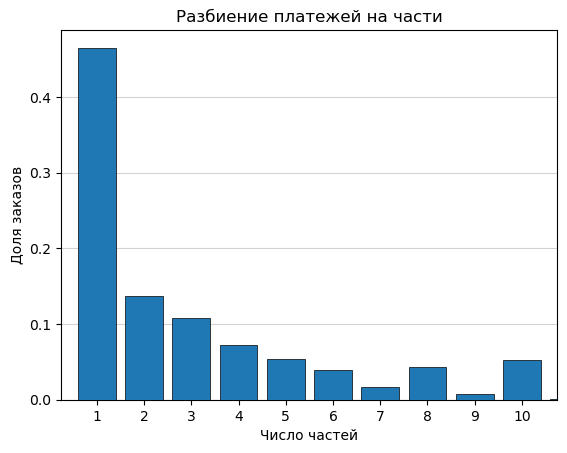

In [87]:
plt.bar(sum_payment_installments.index, sum_payment_installments / sum_payment_installments.sum(), edgecolor='k', linewidth=0.5, zorder=3)
plt.title('Разбиение платежей на части')
plt.ylabel('Доля заказов')
plt.xlabel('Число частей')
plt.xlim([0.25, 10.75])
plt.xticks(range(1, 11))
plt.grid(axis='y', c='lightgrey', zorder=0)
plt.show()

Около половины заказов оплачиваются 1 платежом, остальные платежи разделены на части (преимущественно до 10 частей)

### Revenue analysis

In [90]:
df['revenue'].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    99440.000000
mean       160.990267
std        221.951257
min          0.000000
25%         62.010000
50%        105.290000
75%        176.970000
95%        452.987500
max      13664.080000
Name: revenue, dtype: float64

Сумма заказа очень вариативна, поэтому для визуального анализа исключим из рассмотрения суммы, большие, чем 95% платежей:

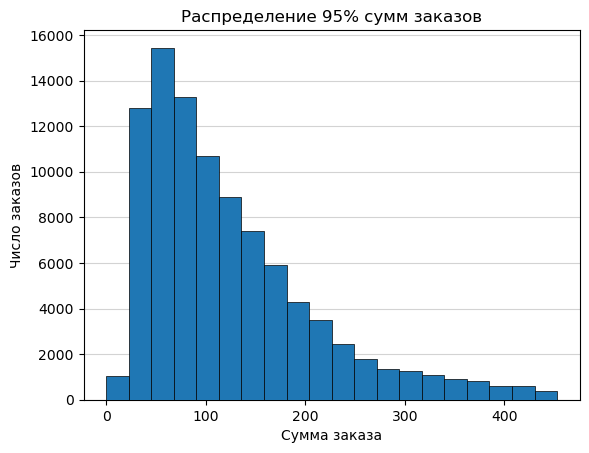

In [92]:
df_95_revenue = df[df['revenue'] <= df['revenue'].quantile(0.95)]

plt.hist(df[df['revenue'] <= df['revenue'].quantile(0.95)]['revenue'], edgecolor='k', bins=20, linewidth=0.5, zorder=3)
plt.title('Распределение 95% сумм заказов')
plt.ylabel('Число заказов')
plt.xlabel('Сумма заказа')
plt.grid(axis='y', c='lightgrey', zorder=0)
plt.show()

На гистограмме распределение сумм заказов скошено вправо, большая часть платежей в диапазоне от 0 до 200-250 ед.

### Revenue dependence on payment installments

Корреляция между размером выручки и числом платежей, на которые разбит платеж, составляет 0.32, что может указывать на тенденцию разбиения более крупных платежей на несколько частей

In [312]:
df[['revenue','payment_installments_count']].corr().round(2)

,revenue,payment_installments_count
revenue,1.00,0.32
payment_installments_count,0.32,1.00


Проверим предположение о том, что более дорогие заказы покупатели склонны оплачивать в несколько плажетей:

In [96]:
many_payments = df.loc[df['payment_installments_count'] > 1, 'revenue']
one_payment = df.loc[df['payment_installments_count'] == 1, 'revenue']

print(f'Медиана суммы заказов с одним платежом: {round(one_payment.median(), 2)} ед.')
print(f'Медиана суммы заказов с несколькими платежами: {round(many_payments.median(), 2)} ед.')

Медиана суммы заказов с одним платежом: 79.33 ед.
Медиана суммы заказов с несколькими платежами: 132.48 ед.


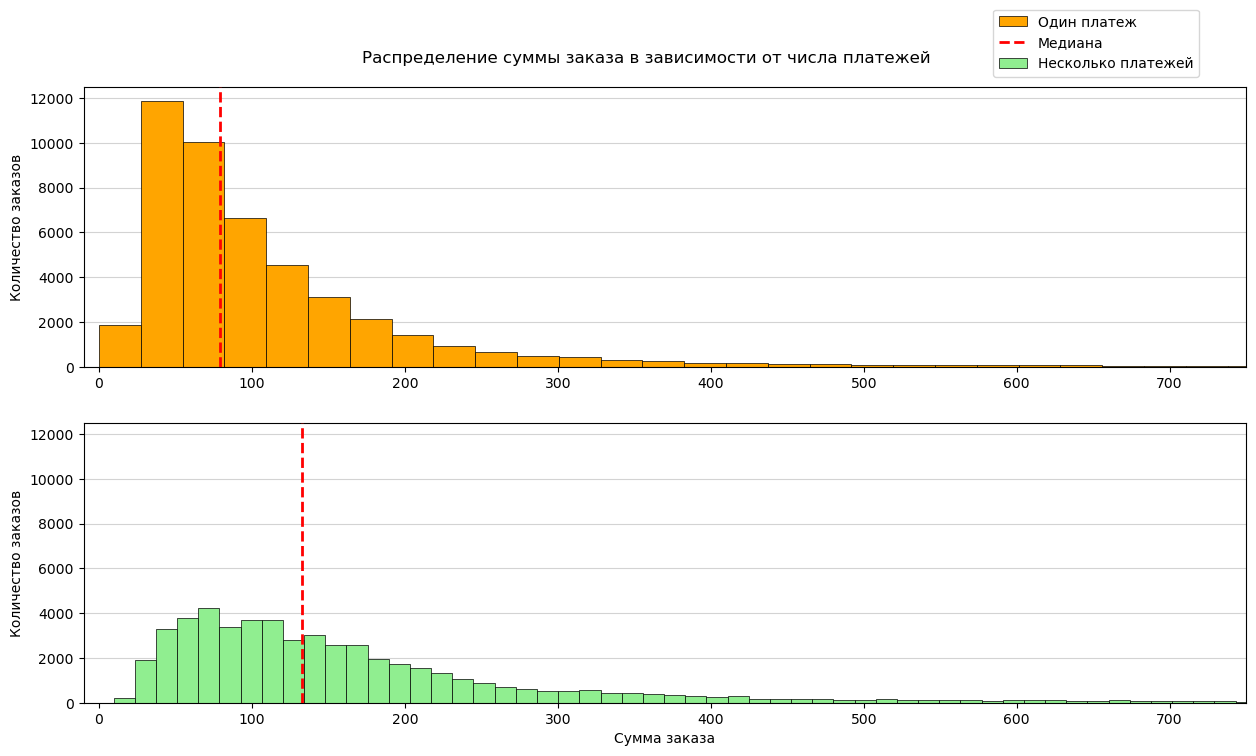

In [97]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].hist(one_payment, bins=500, color='orange', edgecolor='k', linewidth=0.5, label='Один платеж', zorder=2)
axes[0].axvline(x=one_payment.median(), linestyle='--', c='red', zorder=3, linewidth=2, label='Медиана')
axes[0].set_xlim([-10, 750])
axes[0].set_ylim([0, 12_500])
axes[0].set_ylabel('Количество заказов')
axes[0].grid(axis='y', c='lightgrey', zorder=0)

axes[1].hist(many_payments, bins=500, color='lightgreen', edgecolor='k', linewidth=0.5, label='Несколько платежей', zorder=2)
axes[1].axvline(x=many_payments.median(), linestyle='--', c='red', zorder=3, linewidth=2)
axes[1].set_xlim([-10, 750])
axes[1].set_ylim([0, 12_500])
axes[1].set_xlabel('Сумма заказа')
axes[1].set_ylabel('Количество заказов')
axes[1].grid(axis='y', c='lightgrey', zorder=0)

fig.legend(loc='upper center', bbox_to_anchor=(0.8, 0.985))
plt.suptitle('Распределение суммы заказа в зависимости от числа платежей', y=0.925)
plt.show()

In [98]:
normaltest_results = pd.DataFrame({'Размер выборки': [len(one_payment), len(many_payments)],
                                   'shapiro pvalue на подвыборке': [shapiro(one_payment.sample(5000, random_state=23))[1],
                                                                      shapiro(many_payments.sample(5000, random_state=23))[1]]},
                                  index=['Один платеж', 'Несколько платежей'])
normaltest_results

,Размер выборки,shapiro pvalue на подвыборке
Один платеж,46264,6.593309e-85
Несколько платежей,53174,4.127008e-78


Поскольку распределения сумм заказов сильно отличаются от нормальных, для проверки статистической значимости их различия вместо двухвыборочного t-теста используем его непараметрический аналог - критерий Манна-Уитни:

In [100]:
_, pvalue = mannwhitneyu(one_payment, many_payments)
print(f'p-value для критерия Манна-Уитни: {pvalue}')

p-value для критерия Манна-Уитни: 0.0


Критерий Манна-Уитни позволил установить статистически значимое различие между распределениями сумм заказов с одним платежом и несколькими платежами: **заказы, оплаченные несколькими платежами, как правило имеют более высокую сумму**

Вывод подтверждается гистограммами: распределение суммы заказов для нескольких платежей более пологое и его медиана лежит правее

### Order and revenue statistics by purchase month

Рассмотрим распределение выручки по месяцам:

In [105]:
month_groups = df.groupby([df['order_purchase_timestamp'].dt.month, df['order_purchase_timestamp'].dt.month_name()])
month_groups_characteristics = month_groups.agg(orders_count=('order_id', 'size'),
                                                revenue_median=('revenue', 'median'),
                                                revenue_sum=('revenue', 'sum'))
month_groups_characteristics.index = month_groups_characteristics.index.droplevel(level=0)
month_groups_characteristics.index.name = 'purchase_month'
month_groups_characteristics

,orders_count,revenue_median,revenue_sum
purchase_month,,,
January,8069,104.87,1253492.22
February,8508,102.81,1284371.35
March,9893,105.74,1609515.72
April,9343,108.39,1578573.51
May,10573,106.50,1746900.97
June,9412,107.78,1535156.88
July,10318,105.32,1658923.67
August,10843,100.67,1696821.64
September,4305,104.37,732454.23


- В сентябре совершено меньше всего заказов и, соответственно, получена наименьшая суммарная выручка
- В августе совершено больше всего заказов, при этом медианная выручка минимальна
- Апрель характеризуется наибольшей медианной выручкой, а май - наибольшей суммарной выручкой

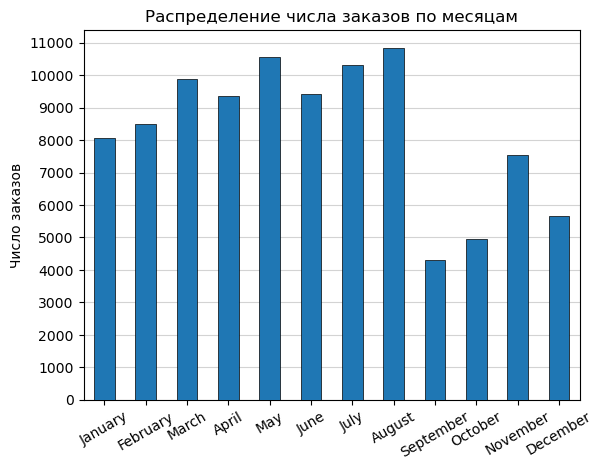

In [107]:
month_groups_characteristics['orders_count'].plot.bar(edgecolor='k', linewidth=0.5, zorder=3)
plt.title('Распределение числа заказов по месяцам')
plt.ylabel('Число заказов')
plt.xlabel('')
plt.xticks(rotation=30)
plt.yticks(range(0, 12_000, 1000))
plt.grid(axis='y', c='lightgrey', zorder=0)
plt.show()

## Delivery analysis

В расчетах ниже как меру центральной тенденции используем медиану, а не среднее, чтобы избежать влияния выбросов:

In [110]:
print(f'Медианное время одобрения заказа: {df['order_approved_at'].sub(df['order_purchase_timestamp']).median().floor('s')}')
print(f'Медианное время передачи заказа перевозчику: {df['order_delivered_carrier_date'].sub(df['order_approved_at']).median().floor('s')}')
print(f'Медианное время доставки заказа перевозчиком: {df['order_delivered_customer_date'].sub(df['order_delivered_carrier_date']).median().floor('s')}')
print(f'Медианное ожидаемое время получения заказа: {df['order_estimated_delivery_date'].sub(df['order_purchase_timestamp']).median().floor('s')}')
print(f'Медианное фактическое время получения заказа: {df['order_delivered_customer_date'].sub(df['order_purchase_timestamp']).median().floor('s')}')

Медианное время одобрения заказа: 0 days 00:20:36
Медианное время передачи заказа перевозчику: 1 days 19:38:29
Медианное время доставки заказа перевозчиком: 7 days 02:23:40
Медианное ожидаемое время получения заказа: 23 days 05:46:08
Медианное фактическое время получения заказа: 10 days 05:13:34


В среднем заказы оказываются у пользователя на 13 дней раньше, чем ожидалось

In [112]:
print(f'Около {round((~df['delivery_delay'].isna()).mean() * 100, 2)}% заказов доставлены не вовремя')
print(f'Среднее опоздание составляет {df[~df['delivery_delay'].isna()]['delivery_delay'].mean().floor('s')}')

Около 7.87% заказов доставлены не вовремя
Среднее опоздание составляет 9 days 13:15:10


## Order items analysis

### Items price

In [115]:
price = order_items['price'].describe()
price.name = 'Распределение цен товаров'
price

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: Распределение цен товаров, dtype: float64

In [116]:
print(f'75% заказанных товаров стояли не дороже {order_items['price'].quantile(0.75)} ед.')

75% заказанных товаров стояли не дороже 134.9 ед.


### Distribution of items counts in an order

In [118]:
items_in_order = order_items.groupby('order_id')['order_item_id'].nunique()
counts_items_in_order = items_in_order.value_counts().sort_index()
counts_items_in_order = counts_items_in_order.to_frame()
counts_items_in_order['percent'] = round(counts_items_in_order['count'] / counts_items_in_order['count'].sum() * 100, 3)
counts_items_in_order.index.name = 'items_count'
counts_items_in_order = counts_items_in_order.rename({'count': 'frequency'}, axis=1)
counts_items_in_order

,frequency,percent
items_count,,
1,88863,90.064
2,7516,7.618
3,1322,1.340
4,505,0.512
5,204,0.207
6,198,0.201
7,22,0.022
8,8,0.008
9,3,0.003


In [119]:
print(f'Около {round(counts_items_in_order.loc[1, 'percent'], 1)}% заказов содержат всего одну позицию')
print(f'Максимальное число позиций в заказе: {max(counts_items_in_order.index)} ед.')

Около 90.1% заказов содержат всего одну позицию
Максимальное число позиций в заказе: 21 ед.


### items popularity

In [121]:
product_counts = order_items.groupby('product_id').size()
product_counts_of_orders = product_counts.value_counts().sort_index()
product_counts_of_orders.index.name = None
product_counts_of_orders.name = 'Число товаров с данным числом продаж (заказов)'
product_counts_of_orders

1      18117
2       5817
3       2651
4       1534
5        994
       ...  
388        1
392        1
484        1
488        1
527        1
Name: Число товаров с данным числом продаж (заказов), Length: 138, dtype: int64

In [122]:
print(f'Большинство товаров заказали всего {product_counts_of_orders.index[0]} раз, наиболее заказываемый товар заказали {product_counts_of_orders.index[-1]} раз')

Большинство товаров заказали всего 1 раз, наиболее заказываемый товар заказали 527 раз


In [123]:
most_popular_product_id = " ".join(product_counts[product_counts==527].index)
print(f'id самого заказываемого товара: {most_popular_product_id}')
print(f'Его средняя цена: {round(order_items[order_items['product_id']==most_popular_product_id]['price'].mean(), 2)} ед.')
print(f'Средняя стоимость его перевозки: {round(order_items[order_items['product_id']==most_popular_product_id]['freight_value'].mean(), 2)} ед.')
print(f'id продавца этого товара: {" ".join(order_items[order_items['product_id']==most_popular_product_id]['seller_id'].unique())}')

id самого заказываемого товара: aca2eb7d00ea1a7b8ebd4e68314663af
Его средняя цена: 71.36 ед.
Средняя стоимость его перевозки: 13.68 ед.
id продавца этого товара: 955fee9216a65b617aa5c0531780ce60


## Product categories analysis

Топ-3 категорий с наибольшим числом товаров: bed_bath_table, sports_leisure, furniture_decor

In [126]:
product_counts = products.groupby('product_category_name')['product_id'].nunique().to_frame().reset_index()
product_counts_eng = pd.merge(product_counts, product_category_name, on='product_category_name', how='left')
product_counts_eng = product_counts_eng.rename({'product_id': 'product_counts'}, axis=1)
product_counts_eng[['product_category_name', 'product_category_name_english', 'product_counts']].sort_values('product_counts', ascending=False)

,product_category_name,product_category_name_english,product_counts
13,cama_mesa_banho,bed_bath_table,3029
32,esporte_lazer,sports_leisure,2867
54,moveis_decoracao,furniture_decor,2657
11,beleza_saude,health_beauty,2444
72,utilidades_domesticas,housewares,2335
...,...,...,...
15,casa_conforto_2,home_comfort_2,5
37,fashion_roupa_infanto_juvenil,fashion_childrens_clothes,5
60,pc_gamer,NaN,3
67,seguros_e_servicos,security_and_services,2


Наиболее дорогие товары в категории computers, самые дешевые - в категории home_comfort_2

In [128]:
product_price = order_items.merge(products, on='product_id', how='left').groupby('product_category_name')['price'].median().reset_index()
product_price_eng = product_price.merge(product_category_name, on='product_category_name', how='left')
product_price_eng = product_price_eng.rename({'price': 'price_median'}, axis=1)
product_price_eng[['product_category_name', 'product_category_name_english', 'price_median']].sort_values('price_median', ascending=False)

,product_category_name,product_category_name_english,price_median
61,pcs,computers,1100.000
64,portateis_casa_forno_e_cafe,small_appliances_home_oven_and_coffee,587.000
0,agro_industria_e_comercio,agro_industry_and_commerce,258.650
29,eletrodomesticos_2,home_appliances_2,225.945
56,moveis_quarto,furniture_bedroom,179.000
...,...,...,...
70,telefonia,telephony,29.990
41,flores,flowers,25.990
30,eletronicos,electronics,21.900
27,dvds_blu_ray,dvds_blu_ray,19.900


В таблице ниже представлены количество проданных товаров в каждой из категорий, средняя и суммарная выручка соответствующих продаж, а также ее процент от суммарной выручки:

In [130]:
categories_sold_items = products.merge(order_items, on='product_id', how='left')
categories_sold_items['revenue'] = categories_sold_items['price'] + categories_sold_items['freight_value']
categories_sold_items_agg = categories_sold_items.groupby('product_category_name').agg(
    sold_items_count=('order_item_id', 'count'),
    revenue_mean=('revenue', 'mean'),
    revenue_sum=('revenue', 'sum')).reset_index().merge(product_category_name, on='product_category_name', how='left')
categories_sold_items_agg['revenue_percent'] = categories_sold_items_agg['revenue_sum'] / categories_sold_items_agg['revenue_sum'].sum() * 100
categories_sold_items_agg = categories_sold_items_agg.set_index('product_category_name_english')
categories_sold_items_agg = categories_sold_items_agg.sort_values('revenue_percent', ascending=False)
categories_sold_items_agg.round({'revenue_percent': 2})

,product_category_name,sold_items_count,revenue_mean,revenue_sum,revenue_percent
product_category_name_english,,,,,
health_beauty,beleza_saude,9670,149.043234,1441248.07,9.22
watches_gifts,relogios_presentes,5991,217.917144,1305541.61,8.35
bed_bath_table,cama_mesa_banho,11115,111.712256,1241681.72,7.94
sports_leisure,esporte_lazer,8641,133.856785,1156656.48,7.40
computers_accessories,informatica_acessorios,7827,135.335684,1059272.40,6.77
...,...,...,...,...,...
flowers,flores,33,48.451818,1598.91,0.01
home_comfort_2,casa_conforto_2,30,39.019333,1170.58,0.01
cds_dvds_musicals,cds_dvds_musicais,14,68.213571,954.99,0.01


Всего 7 из 73 представленных категорий товаров вносят 50% вклад в сумммарную выручку от продаж

In [132]:
categories_sold_items_agg['cumulative_revenue_percent'] = categories_sold_items_agg['revenue_percent'].expanding().sum()
categories_sold_items_agg.round({'revenue_percent': 2, 'cumulative_revenue_percent': 2}).head(7)

,product_category_name,sold_items_count,revenue_mean,revenue_sum,revenue_percent,cumulative_revenue_percent
product_category_name_english,,,,,,
health_beauty,beleza_saude,9670,149.043234,1441248.07,9.22,9.22
watches_gifts,relogios_presentes,5991,217.917144,1305541.61,8.35,17.57
bed_bath_table,cama_mesa_banho,11115,111.712256,1241681.72,7.94,25.51
sports_leisure,esporte_lazer,8641,133.856785,1156656.48,7.40,32.91
computers_accessories,informatica_acessorios,7827,135.335684,1059272.40,6.77,39.68
furniture_decor,moveis_decoracao,8334,108.292751,902511.79,5.77,45.45
housewares,utilidades_domesticas,6964,111.774522,778397.77,4.98,50.43


## Geolocation analysis

### Aggregated metrics by customer city

Всего заказы совершались из 4119 городов, при этом топ-5 наиболее частых городов: Сан-Паулу, Рио-де-Жанейро, Белу-Оризонти, Бразилиа и Куритиба

In [136]:
order_cities_counts = df['customer_city'].value_counts()
order_cities_counts.index.name = None
order_cities_counts.name = 'Количество заказов из городов'
order_cities_counts

sao paulo           15540
rio de janeiro       6882
belo horizonte       2773
brasilia             2131
curitiba             1521
                    ...  
vila nova do sul        1
cuite velho             1
novais                  1
jacuipe                 1
nova vicosa             1
Name: Количество заказов из городов, Length: 4119, dtype: int64

In [137]:
customer_nunique_cities = df.groupby('customer_unique_id').agg(nunique_cities=('customer_city', lambda cities: cities.nunique()))
non_unique_city_customers = customer_nunique_cities[customer_nunique_cities['nunique_cities'] > 1]
print(f'За период сбора данных заказывали из разных городов: {non_unique_city_customers.shape[0]} чел.')

За период сбора данных заказывали из разных городов: 122 чел.


Различных городов слишком много, рассмотрим только города, количество заказов из которых не меньше 1% от общего числа заказов:

In [139]:
order_cities_counts_df = order_cities_counts.to_frame()
order_cities_counts_df['percent_of_total_orders'] = order_cities_counts_df['Количество заказов из городов'] / order_cities_counts_df['Количество заказов из городов'].sum() * 100
most_active_cities_counts = order_cities_counts_df[order_cities_counts_df['percent_of_total_orders'] >= 1]
most_active_cities = most_active_cities_counts.index
most_active_cities_counts = most_active_cities_counts.rename(columns={'Количество заказов из городов': 'orders_count'})
most_active_cities_counts['percent_of_total_orders'] = round(most_active_cities_counts['percent_of_total_orders'], 2)
most_active_cities_counts.index.name = 'city'
most_active_cities_counts

,orders_count,percent_of_total_orders
city,,
sao paulo,15540,15.63
rio de janeiro,6882,6.92
belo horizonte,2773,2.79
brasilia,2131,2.14
curitiba,1521,1.53
campinas,1444,1.45
porto alegre,1379,1.39
salvador,1245,1.25
guarulhos,1189,1.20


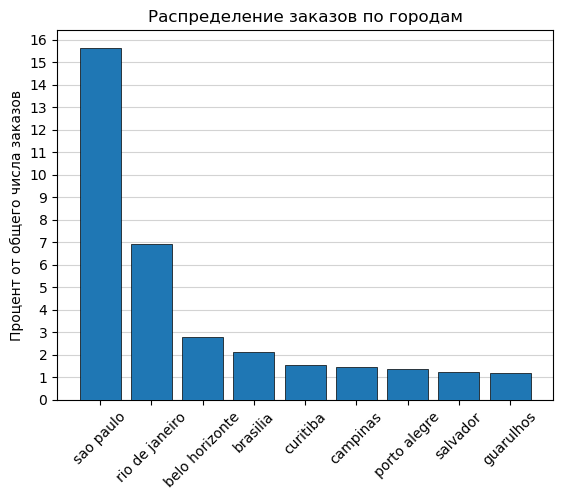

In [140]:
plt.bar(most_active_cities_counts.index, most_active_cities_counts['percent_of_total_orders'], edgecolor='k', linewidth=0.5, zorder=3)
plt.title('Распределение заказов по городам')
plt.xticks(rotation=45)
plt.yticks(range(0, 17))
plt.ylabel('Процент от общего числа заказов')
plt.grid(axis='y', c='lightgrey', zorder=0)
plt.show()

Посмотрим на основные характеристики данных городов:

In [142]:
city_groups = df[df['customer_city'].isin(most_active_cities)].groupby('customer_city')
city_groups_characteristics = city_groups.agg(
    orders_count=('order_id', 'nunique'),
    n_unique_customers=('customer_unique_id', 'nunique'),
    revenue_median=('revenue', 'median'),
    revenue_sum=('revenue', 'sum'),
    percent_of_not_delivered_orders=('order_status', lambda status: round((status.isin(['canceled', 'unavailable'])).sum() / len(status) * 100, 2)),
    delivery_time_median=('delivery_time', lambda dt: dt.median().floor('s')),
    percent_of_delivery_delays=('delivery_delay', lambda delay: round((~delay.isna()).mean()*100, 2))).sort_values('orders_count', ascending=False)
    
city_groups_characteristics.insert(2, 'orders_per_customer', round(city_groups_characteristics['orders_count'] / city_groups_characteristics['n_unique_customers'], 4))
city_groups_characteristics.insert(5, 'revenue_per_customer', round(city_groups_characteristics['revenue_sum'] / city_groups_characteristics['n_unique_customers'], 2))
city_groups_characteristics.index.name = 'city'
city_groups_characteristics

,orders_count,n_unique_customers,orders_per_customer,revenue_median,revenue_sum,revenue_per_customer,percent_of_not_delivered_orders,delivery_time_median,percent_of_delivery_delays
city,,,,,,,,,
sao paulo,15540,14984,1.0371,92.125,2203373.09,147.05,1.60,6 days 12:49:16,6.06
rio de janeiro,6882,6620,1.0396,109.725,1161927.36,175.52,1.18,11 days 18:05:24,11.33
belo horizonte,2773,2672,1.0378,103.830,421765.12,157.85,1.30,9 days 08:30:00,5.99
brasilia,2131,2069,1.0300,108.180,354216.78,171.20,0.89,11 days 08:42:12,6.90
curitiba,1521,1465,1.0382,102.660,247392.48,168.87,1.25,8 days 22:42:40,4.87
campinas,1444,1398,1.0329,92.760,216248.43,154.68,1.52,8 days 01:14:04,9.90
porto alegre,1379,1326,1.0400,112.950,224731.42,169.48,0.65,13 days 03:55:53,11.46
salvador,1245,1209,1.0298,113.850,218071.50,180.37,0.88,17 days 04:03:50,16.71
guarulhos,1189,1153,1.0312,95.670,165121.99,143.21,1.85,6 days 20:57:02,6.06


- Сан-Паулу характеризуется наибольшим количеством заказов и уникальных клиентов, при этом для этого города получены наименьшая медиана выручки и наименьшая медиана длительности доставки, а суммарная выручка оказалась самой большой
- Порту-Алегри отличается максимальным числом заказов на пользователя и наименьшим процентом недоставленных заказов
- Для г. Салвадор характерно минимальное число заказов на пользователя и одновременно наибольшая медиана суммы заказа, максимальная выручка на пользователя, максимальная медианная длительность доставки и наибольший процент задержанных по доставке заказов
- Заказы в г. Гуарульюс не доставляются чаще остальных и приносят наименьшую выручку на пользователя
- Реже всего задерживаются заказы в г. Куритиба

### Customers and sellers states distribution

In [145]:
nunique_customer_states = df.groupby('customer_unique_id')['customer_state'].nunique()
several_states_customer_ids = nunique_customer_states[nunique_customer_states > 1].index
print(f'Заказывали в разные штаты {round((nunique_customer_states > 1).mean() * 100, 2)}% покупателей')

Заказывали в разные штаты 0.04% покупателей


Поскольку всего 0.04% покупателей заказывали товары в разные штаты, при анализе распределения покупателей по штатам этих покупателей можно исключить из рассмотрения:

In [147]:
unique_customer_states = df[~df['customer_unique_id'].isin(several_states_customer_ids)] \
    .groupby('customer_unique_id') \
    .agg(customer_state=('customer_state', 'first'))

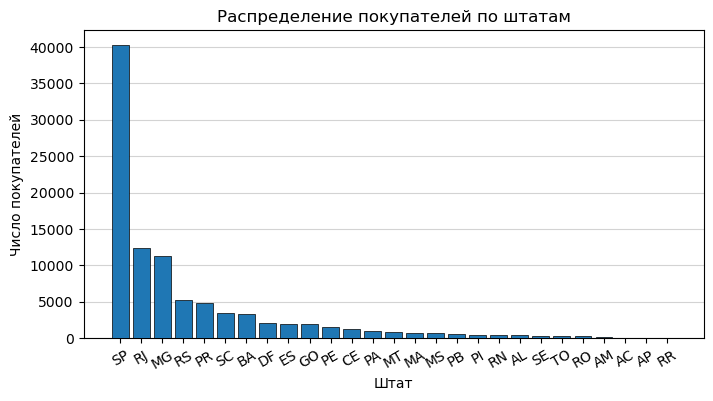

In [148]:
customer_states_counts = unique_customer_states['customer_state'].value_counts()

plt.figure(figsize=(8, 4))
plt.bar(customer_states_counts.index, customer_states_counts, edgecolor='k', linewidth=0.5, zorder=3)
plt.xticks(rotation=30)
plt.grid(axis='y', c='lightgrey', zorder=0)
plt.title('Распределение покупателей по штатам')
plt.xlabel('Штат')
plt.ylabel('Число покупателей')
plt.show()

Основная часть заказов доставляется в штат Сан-Паулу

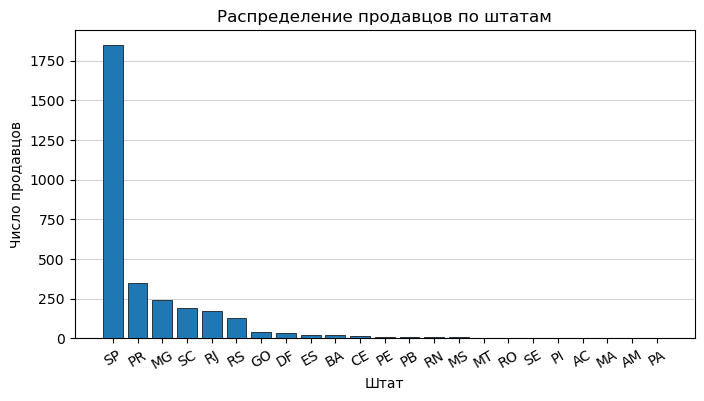

In [151]:
sellers_states_counts = sellers['seller_state'].value_counts()

plt.figure(figsize=(8, 4))
plt.bar(sellers_states_counts.index, sellers_states_counts, edgecolor='k', linewidth=0.5, zorder=3)
plt.xticks(rotation=30)
plt.grid(axis='y', c='lightgrey', zorder=0)
plt.title('Распределение продавцов по штатам')
plt.xlabel('Штат')
plt.ylabel('Число продавцов')
plt.show()

Как и для покупателей, Сан-Паулу является самым распространенным штатом среди локаций продавцов

## Reviews analysis

Среди отзывов на заказы преобладают положительные, однако доля оценок, равных 1, довольно велика

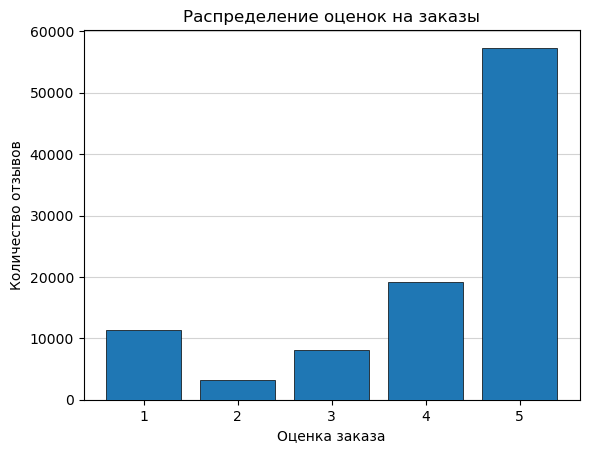

In [155]:
scores_counts = order_reviews['review_score'].value_counts().sort_index()
plt.bar(scores_counts.index, scores_counts, edgecolor='k', linewidth=0.5, zorder=3)
plt.title('Распределение оценок на заказы')
plt.xlabel('Оценка заказа')
plt.ylabel('Количество отзывов')
plt.grid(axis='y', c='lightgrey', zorder=0)
plt.show()

### Review score changes

In [157]:
order_reviews.groupby('review_score').agg(orders_count=('order_id', 'size'), orders_nunique=('order_id', 'nunique'))

,orders_count,orders_nunique
review_score,,
1,11424,11393
2,3151,3148
3,8179,8160
4,19142,19098
5,57328,57076


Из таблицы видно, что на некоторые заказы покупатели оставляют более одного отзыва

In [159]:
reviews_groups = order_reviews.sort_values('review_creation_date').groupby('order_id', sort=False).agg(
    reviews_count=('review_id', 'nunique'),
    first_score=('review_score', 'first'),
    last_score=('review_score', 'last'),
)
reviews_groups['reviews_count'].value_counts()

reviews_count
1    98126
2      543
3        4
Name: count, dtype: int64

На 543 заказа было оставлено 2 отзыва, на 4 заказа отзыв менялся трижды  
В таблице указано количество отзывов для заказов с более чем 1 отзывом, а также первая и последняя оценка

In [161]:
non_unique_review_order_ids = reviews_groups[reviews_groups['reviews_count'] > 1]
non_unique_review_order_ids.head()

,reviews_count,first_score,last_score
order_id,,,
b19169c7cb8391fb8561e094d61c531a,2,5,5
c4f710df20f7d1500da1aef81a993f65,2,5,5
b6e5aa946acc4e29e7069510f28a0bce,2,5,5
2a3d67c0d2045bf67abb3d8f320ac29f,2,5,5
9c54a1816e487456bb7eb5082b9823ff,2,5,4


In [162]:
scores_delta = reviews_groups[reviews_groups['reviews_count'] > 1]['last_score'] - \
    reviews_groups[reviews_groups['reviews_count'] > 1]['first_score']
scores_delta_counts = scores_delta.value_counts().sort_index()
scores_delta_counts.name = 'Частота изменений оценок на заказ'
scores_delta_counts

-4     26
-3     20
-2     22
-1     50
 0    345
 1     40
 2     25
 3     12
 4      7
Name: Частота изменений оценок на заказ, dtype: int64

In [163]:
print(f'Оценка ухудшалась в {round(scores_delta_counts.loc[-4:-1].sum() / scores_delta_counts.sum() * 100, 2)}% случаев')
print(f'Оценка не изменялась в {round(scores_delta_counts.loc[0].sum() / scores_delta_counts.sum() * 100, 2)}% случаев')
print(f'Оценка улучшалась в {round(scores_delta_counts.loc[1:4].sum() / scores_delta_counts.sum() * 100, 2)}% случаев')

Оценка ухудшалась в 21.57% случаев
Оценка не изменялась в 63.07% случаев
Оценка улучшалась в 15.36% случаев


Чаще всего оценка на заказ не менялась, положительных изменений оценки меньше, чем отрицательных, приблизительно на 6%

### Score dependence on comment

В таблице отзывов на заказы большое количество отсутствующих значений в столбцах заголовка и комментария к отзыву:

In [167]:
na_perc = round(order_reviews.isna().sum() / order_reviews.shape[0] * 100, 2)
na_perc.index.name = None
na_perc.name = 'Процент отсутствующих значений'
na_perc

review_id                   0.00
order_id                    0.00
review_score                0.00
review_comment_title       88.34
review_comment_message     58.70
review_creation_date        0.00
review_answer_timestamp     0.00
Name: Процент отсутствующих значений, dtype: float64

Сравним распределения оценок на заказы в зависимости от наличия комментария к отзыву:

In [169]:
mask_text = order_reviews['review_comment_message'].isna()

review_scores_without_text = order_reviews.loc[mask_text, 'review_score']
mean_without_text = review_scores_without_text.mean()

review_scores_with_text = order_reviews.loc[~mask_text, 'review_score']
mean_with_text = review_scores_with_text.mean()

print(f'Средняя оценка заказа без комментария в отзыве: {round(mean_without_text, 3)}')
print(f'Средняя оценка заказа с комментарием в отзыве: {round(mean_with_text, 3)}')

Средняя оценка заказа без комментария в отзыве: 4.379
Средняя оценка заказа с комментарием в отзыве: 3.67


Средняя оценка в отзывах без комментария значительно выше  
Проверим статистическую значимость различия распределений оценок на заказы в зависимости от наличия комментария в отзыве с помощью критерия Манна-Уитни (распределения оценок дискретные и ненормальные):

In [171]:
_, pvalue = mannwhitneyu(review_scores_without_text, review_scores_with_text)
print(f'p-value для критерия Манна-Уитни: {pvalue}')

p-value для критерия Манна-Уитни: 0.0


Критерий показал статистическую значимость различия распределений оценок на заказы с комментарием в отзыве и без него: **покупатели чаще оставляют комментарии в случае негативного опыта, а при положительном опыте ограничиваются выставлением оценки**

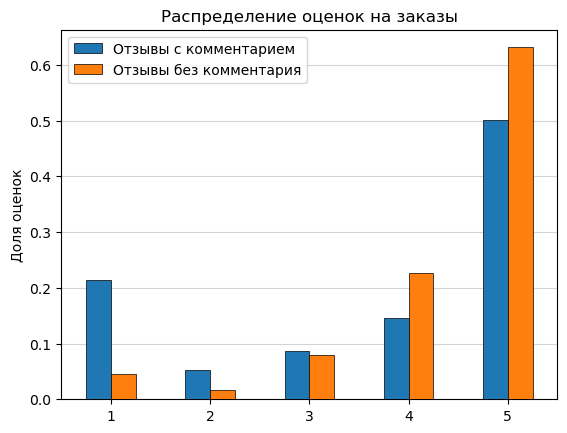

In [173]:
pd.DataFrame(
    {'Отзывы с комментарием': review_scores_with_text.value_counts(normalize=True).sort_index(),
     'Отзывы без комментария': review_scores_without_text.value_counts(normalize=True).sort_index()}
).plot(kind='bar', edgecolor='k', linewidth=0.5, zorder=3)
plt.title('Распределение оценок на заказы')
plt.xticks(rotation=0)
plt.xlabel('')
plt.ylabel('Доля оценок')
plt.grid(axis='y', c='lightgrey', zorder=0)

Вывод подтверждается на графике: **для низких оценок доля отзывов с комментарием выше**

### Review answer time dependence on score

Проверим также предположение о том, что на отзыв с низкой оценкой ответ будет дан раньше, чем на отзыв с высокой оценкой (для создания отзыва указана только дата без времени, что может искажать результаты):

In [177]:
order_reviews[['review_creation_date', 'review_answer_timestamp']] = order_reviews[['review_creation_date', 'review_answer_timestamp']].apply(pd.to_datetime)

order_reviews['time_before_answer'] = order_reviews['review_answer_timestamp'].sub(order_reviews['review_creation_date'])
order_reviews['time_before_answer'].name = 'Время ответа на отзыв'
order_reviews['time_before_answer']

0       0 days 21:46:59
1       1 days 03:05:13
2       1 days 14:36:24
3       0 days 22:02:06
4       1 days 10:26:53
              ...      
99219   7 days 17:18:30
99220   2 days 20:06:42
99221   1 days 09:10:43
99222   1 days 12:59:13
99223   0 days 21:01:49
Name: Время ответа на отзыв, Length: 99224, dtype: timedelta64[ns]

In [178]:
order_reviews['time_before_answer'].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count                        99224
mean     3 days 03:34:33.029700475
std      9 days 21:21:40.258026234
min                0 days 02:08:29
25%         1 days 00:07:00.750000
50%         1 days 16:11:55.500000
75%                3 days 02:29:08
95%      6 days 23:19:57.199999999
max              518 days 16:46:52
Name: Время ответа на отзыв, dtype: object

В среднем на отзыв отвечают через 3 дня 3.5 часа  
На 95% отзывов отвечают в течение 7 дней

In [180]:
order_reviews_low_score = order_reviews[order_reviews['review_score'].isin([1, 2])]
order_reviews_high_score = order_reviews[order_reviews['review_score'].isin([4, 5])]

median_answer_time_low = order_reviews_low_score['time_before_answer'].median().floor('s')
median_answer_time_high = order_reviews_high_score['time_before_answer'].median().floor('s')

print(f'Медиана времени ответа на отзывы с оценками 1 и 2: {median_answer_time_low}')
print(f'Медиана времени ответа на отзывы с оценками 4 и 5: {median_answer_time_high}')

Медиана времени ответа на отзывы с оценками 1 и 2: 1 days 13:58:39
Медиана времени ответа на отзывы с оценками 4 и 5: 1 days 16:25:04


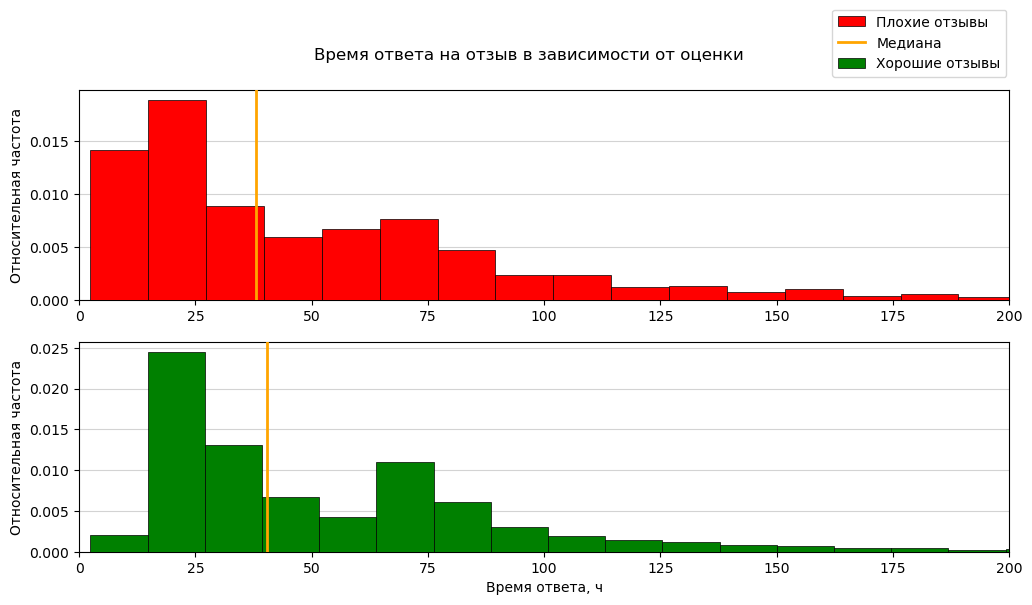

In [181]:
answer_time_low = order_reviews_low_score['time_before_answer'].apply(lambda td: td.total_seconds()/3600)
answer_time_high = order_reviews_high_score['time_before_answer'].apply(lambda td: td.total_seconds()/3600)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].hist(answer_time_low, bins=1000, density=True, color='red', edgecolor='k', linewidth=0.5, label='Плохие отзывы', zorder=3)
axes[0].set_xlim([0, 200])
axes[0].set_ylabel('Относительная частота')
axes[0].axvline(x=(answer_time_low).median(), c='orange', linewidth=2, label='Медиана', zorder=3)
axes[0].grid(axis='y', c='lightgrey', zorder=0)

axes[1].hist(answer_time_high, bins=1000, density=True, color='green', edgecolor='k', linewidth=0.5, label='Хорошие отзывы', zorder=3)
axes[1].set_xlim([0, 200])
axes[1].set_ylabel('Относительная частота')
axes[1].set_xlabel('Время ответа, ч')
axes[1].axvline(x=(answer_time_high).median(), c='orange', linewidth=2, zorder=3)
axes[1].grid(axis='y', c='lightgrey', zorder=0)

fig.legend(loc='upper center', bbox_to_anchor=(0.825, 1.025))
plt.suptitle('Время ответа на отзыв в зависимости от оценки', y=0.95)
plt.show()

Проверим статистическую значимость вычисленной разницы во времени ответа на отзыв, используя критерий Манна-Уитни (распределения выборок далеки от нормального):

In [183]:
_, pvalue = mannwhitneyu(answer_time_low, answer_time_high)
print(f'p-value для критерия Манна-Уитни: {pvalue}')

p-value для критерия Манна-Уитни: 1.820431649954902e-111


Так как pvalue < 0.05, то есть основания полагать, что распределения времени ответа на отзыв в зависимости от оценки заказа статистически значимо отличаются: **на плохой отзыв отвечают в среднем быстрее, чем на хороший**

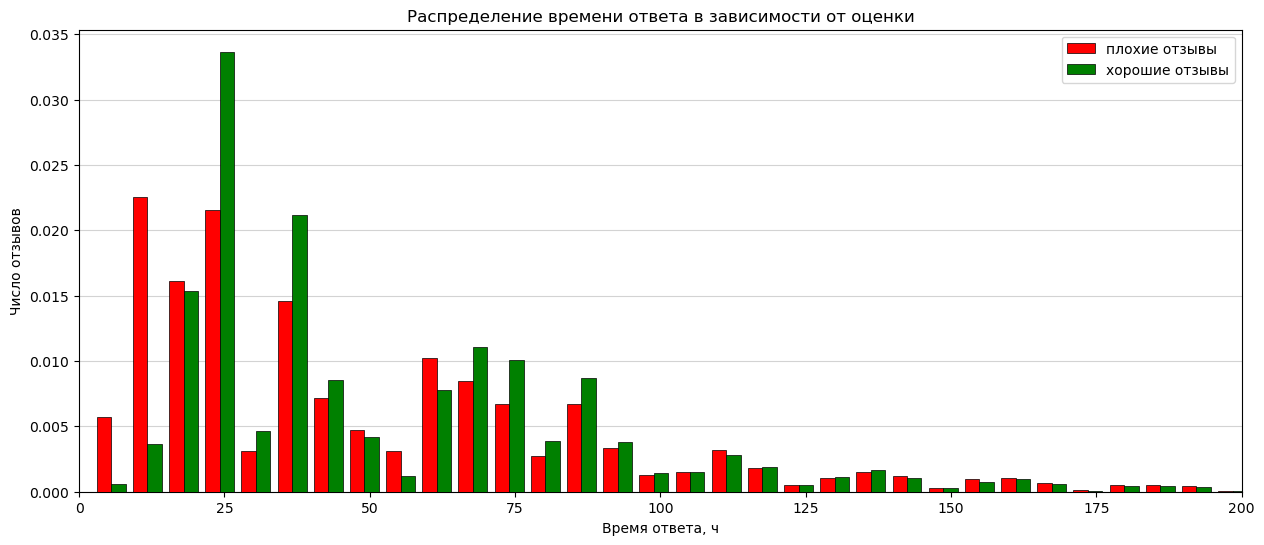

In [185]:
plt.figure(figsize=(15, 6))
plt.hist([answer_time_low, answer_time_high], bins = 2000, label=['плохие отзывы', 'хорошие отзывы'], color=['red','green'],
         edgecolor='k', linewidth=0.5, zorder=3, density=True)
plt.xlim([0, 200])
plt.title('Распределение времени ответа в зависимости от оценки')
plt.xlabel('Время ответа, ч')
plt.ylabel('Число отзывов')
plt.grid(axis='y', c='lightgrey', zorder=0)
plt.legend()
plt.show()

Вывод подтверждается на графике: **для малого времени ответа характерно преобладание доли негативных отзывов**

### Revenue dependence on score

Для анализа зависимости выручки от оценки заказа для удобства исключим из рассмотрения малое количество заказов, на которые оставили более 1 отзыва:

In [189]:
unique_reviews_orders = orders[~orders['order_id'].isin(non_unique_review_order_ids.index)] \
    .merge(order_reviews, on='order_id') \
    .merge(order_payments, on='order_id')

unique_reviews_orders_agg = unique_reviews_orders.groupby('order_id').agg(
    review_score=('review_score', 'first'),
    revenue=('payment_value', 'sum')
).reset_index()

unique_reviews_orders_agg.head()

,order_id,review_score,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,5,72.19
1,00018f77f2f0320c557190d7a144bdd3,4,259.83
2,000229ec398224ef6ca0657da4fc703e,5,216.87
3,00024acbcdf0a6daa1e931b038114c75,4,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,5,218.04


In [190]:
unique_reviews_orders_scores_groups = unique_reviews_orders_agg.groupby('review_score')
unique_reviews_orders_scores_groups.agg(
    orders_count=('order_id', 'nunique'),
    revenue_mean=('revenue', 'mean'),
    revenue_median=('revenue', 'median'),
    normaltest_pvalue=('revenue', lambda revenue: normaltest(revenue)[1])).round({'revenue': 2})

,orders_count,revenue_mean,revenue_median,normaltest_pvalue
review_score,,,,
1,11285,195.950001,120.000,0.0
2,3110,172.854299,112.310,0.0
3,8076,151.760796,103.265,0.0
4,18949,154.969384,102.920,0.0
5,56705,156.527615,103.370,0.0


Средние значения и медианы выручки в зависимости от оценки заказа заметно отличаются: **для заказов с оценками 1 и 2 среднее и медиана выручки выше, чем для остальных групп**  
Распределения этих выручек не проходят тест на нормальность, поэтому для проверки статистической значимости различия распределений (медиан) групп вместо однофакторного ANOVA используем непараметрический критерий Краскела-Уоллиса:

In [192]:
groups = {score: unique_reviews_orders_scores_groups.get_group(score)['revenue'] for score in range(1, 6)}
_, pvalue = kruskal(*groups.values())
print(f'p-value для критерия Краскела-Уоллиса: {pvalue}')

p-value для критерия Краскела-Уоллиса: 8.429915124792665e-85


Критерий Краскела-Уоллиса дает основания полагать, что распределения сумм заказов для разных оценок отличаются статистически значимо, для выявления попарных различий между выборками проведем post-hoc сравнения критерием Манна-Уитни, используя поправку Бонферрони:

In [194]:
pairs = list(combinations(groups.keys(), 2))
results = []

for first, second in pairs:
    _, p = mannwhitneyu(groups[first], groups[second])
    results.append({'first_score_group': first, 'second_score_group': second, 'p_uncorrected': p})

results_df = pd.DataFrame(results)
results_df['p_bonferroni'] = results_df['p_uncorrected'] * len(pairs)
results_df['p_bonferroni'] = np.where(results_df['p_bonferroni'] > 1, 1., results_df['p_bonferroni'])
results_df

,first_score_group,second_score_group,p_uncorrected,p_bonferroni
0,1,2,2.579802e-06,2.579802e-05
1,1,3,2.096842e-41,2.096842e-40
2,1,4,5.013914e-62,5.013914e-61
3,1,5,2.541590e-79,2.541590e-78
4,2,3,1.299097e-06,1.299097e-05
5,2,4,1.009072e-07,1.009072e-06
6,2,5,5.219259e-08,5.219259e-07
7,3,4,9.667228e-01,1.000000e+00
8,3,5,8.904600e-01,1.000000e+00
9,4,5,7.968411e-01,1.000000e+00


Вычленим пары групп со статистически значимыми различиями:

In [196]:
results_df[results_df['p_bonferroni'] < 0.5]

,first_score_group,second_score_group,p_uncorrected,p_bonferroni
0,1,2,2.579802e-06,2.579802e-05
1,1,3,2.096842e-41,2.096842e-40
2,1,4,5.013914e-62,5.013914e-61
3,1,5,2.541590e-79,2.541590e-78
4,2,3,1.299097e-06,1.299097e-05
5,2,4,1.009072e-07,1.009072e-06
6,2,5,5.219259e-08,5.219259e-07


Получили статистически значимые различия в распределениях выручек для заказов с оценками 1 и 2, 1 и 3, 1 и 4, 1 и 5, 2 и 3, 2 и 4, 2 и 5  
Таким образом, подтвердилось первоначальное наблюдение о том, что распределения выручки в заказах с низкими оценками отличаются от заказов с оценками выше, что может быть обусловлено тем, что на более дорогой заказ покупатель возлагает большие надежды и вследствие этого с большей вероятностью может остаться недоволен

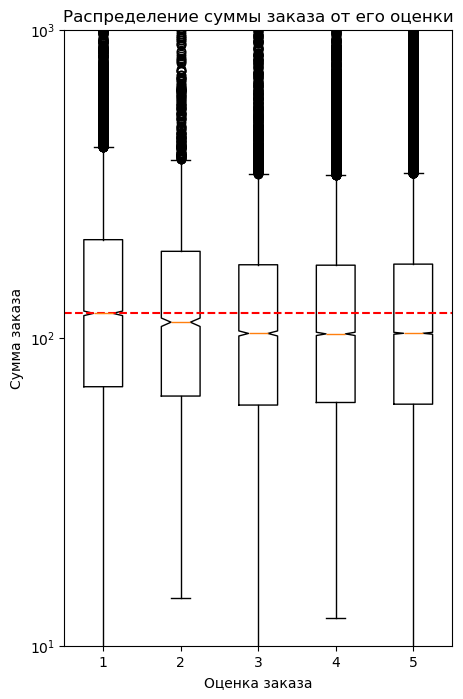

In [198]:
plt.figure(figsize=(5, 8))
plt.boxplot(groups.values(), tick_labels=groups.keys(), notch=True)
plt.yscale('symlog', linthresh=1) # для визуального сжатия хвостов распределений
plt.ylim([10, 1000]) # для большей наглядности
plt.axhline(groups[1].median(), c='r', linestyle='--')
plt.title('Распределение суммы заказа от его оценки')
plt.xlabel('Оценка заказа')
plt.ylabel('Сумма заказа')
plt.show()

На коробчатых диаграммах визуализируется разница в распределениях выручки для заказов с низкими и высокими оценками, согласующаяся с результатами теста: **заказы с оценками 1 и 2 чаще имеют более высокую стоимость**